In [40]:
# BTC VS Major Indices: Returns & correlation Analysis
# Data Source: Yahoo Finance via yfinance
# Reference: Python for Finanfe, Chapter 8

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Tickers and time period

tickers = {
    'BTC': 'BTC-USD',
    'SP500': '^GSPC',
    'NASDAQ': '^IXIC',
    'DOW': '^DJI'
}

# Downlad 10 years of data
raw_data = yf.download(
    list(tickers.values()),
    start='2015-01-01',
    end='2026-05-04'
) ['Close']

[*********************100%***********************]  4 of 4 completed


In [15]:
# Rename columns to be readable
raw_data.columns = ['BTC', 'DOW', 'NASDAQ', 'SP500']

print(raw_data.head())
print(raw_data.shape)

                   BTC           DOW       NASDAQ        SP500
Date                                                          
2015-01-01  314.248993           NaN          NaN          NaN
2015-01-02  315.032013  17832.990234  2058.199951  4726.810059
2015-01-03  281.082001           NaN          NaN          NaN
2015-01-04  264.195007           NaN          NaN          NaN
2015-01-05  274.473999  17501.650391  2020.579956  4652.569824
(4141, 4)


In [16]:
# Calculate daily logarithmic returns
# Reference: Python for Finance, Chapter 8, page 222
# Why use log returns instead of price?  Puts all assets on same scale regardlesss of price

returns = np.log(raw_data / raw_data.shift(1))

# Dropping NaN values - aligns our dates where ALL assets have data
returns = returns.dropna()

print("Returns Shape:" , returns.shape)
print("\nFirst few rows of returns:")
print(returns.head())
print("\nBasic Statistics:")

Returns Shape: (2229, 4)

First few rows of returns:
                 BTC       DOW    NASDAQ     SP500
Date                                              
2015-01-06  0.041796 -0.007456 -0.008933 -0.012943
2015-01-07  0.028073  0.012180  0.011563  0.012491
2015-01-08 -0.038046  0.018221  0.017730  0.018265
2015-01-09  0.024607 -0.009567 -0.008439 -0.006805
2015-01-13 -0.170306 -0.001541 -0.002582 -0.000688

Basic Statistics:


In [ ]:
# Quick peek: let's look at recent performance 2023-2026 returns

recent = raw_data['2023-01-01':].dropna()
print("Recent Data (2023-present):")
print(recent.tail())

# Calculate total return for each asset since 2023

total_returns = ((recent.iloc[-1] - recent.iloc[0]) / recent.iloc[0] * 100)
print("\nTotal return since 2023: ")
print(total_returns.round(2))
print("%")

Recent Data (2023-present):
                     BTC           DOW       NASDAQ         SP500
Date                                                             
2026-04-27  77366.625000  49167.789062  7173.910156  24887.099609
2026-04-28  76350.671875  49141.929688  7138.799805  24663.800781
2026-04-29  75776.132812  48861.808594  7135.950195  24673.240234
2026-04-30  76304.320312  49652.140625  7209.009766  24892.310547
2026-05-01  78179.000000  49499.269531  7230.120117  25114.439453

Total return since 2023: 
BTC       368.70
DOW        49.38
NASDAQ     89.07
SP500     141.79
dtype: float64
%


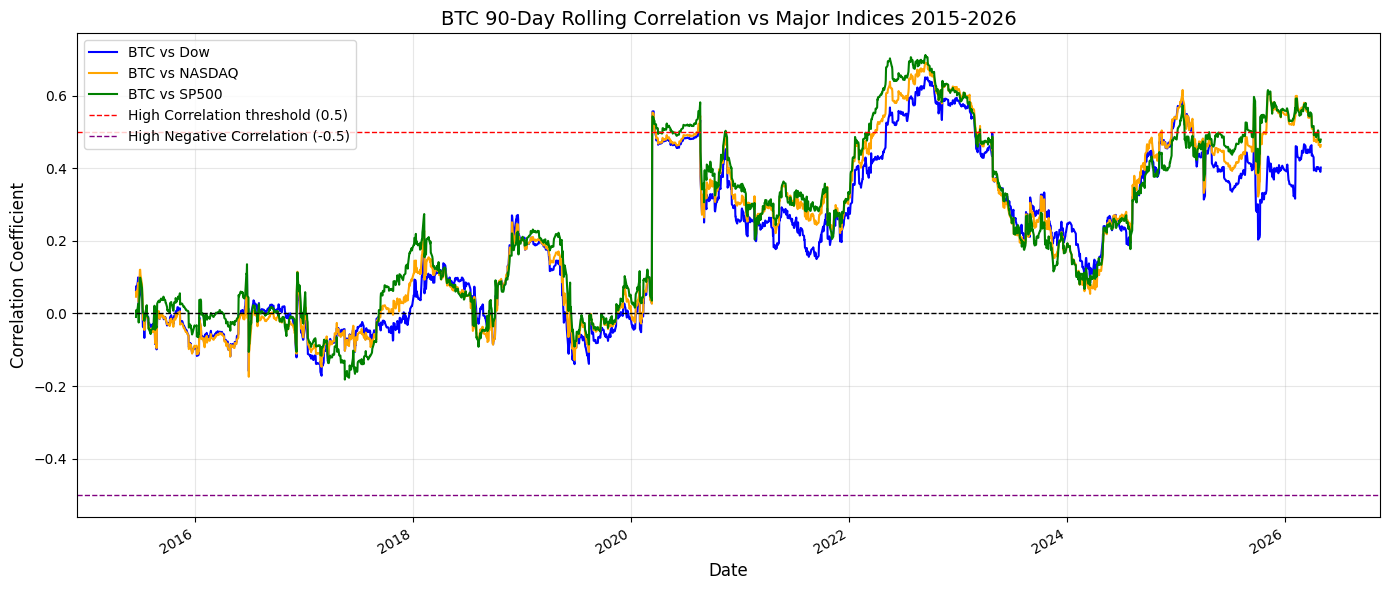

In [19]:
# Rolling 90-day correlation between BTC and each index
# Reference: Python for Finance, Chapter 8, page 217 - Rolling Statistics

fig, ax = plt.subplots(figsize=(14, 6))

# Calculate and plot roling correlation for each index

returns['BTC'].rolling(90).corr(returns['DOW']).plot(
    ax=ax, label='BTC vs Dow', color='blue')
returns['BTC'].rolling(90).corr(returns['NASDAQ']).plot(
    ax=ax, label='BTC vs NASDAQ', color='orange')
returns['BTC'].rolling(90).corr(returns['SP500']).plot(
    ax=ax, label='BTC vs SP500', color='green')

# lets add refrence line

# Reference lines
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.axhline(y=0.5, color='red', linestyle='--', 
           linewidth=1, label='High Correlation threshold (0.5)')
ax.axhline(y=-0.5, color='purple', linestyle='--', 
           linewidth=1, label='High Negative Correlation (-0.5)')

ax.set_title('BTC 90-Day Rolling Correlation vs Major Indices 2015-2026', 
             fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

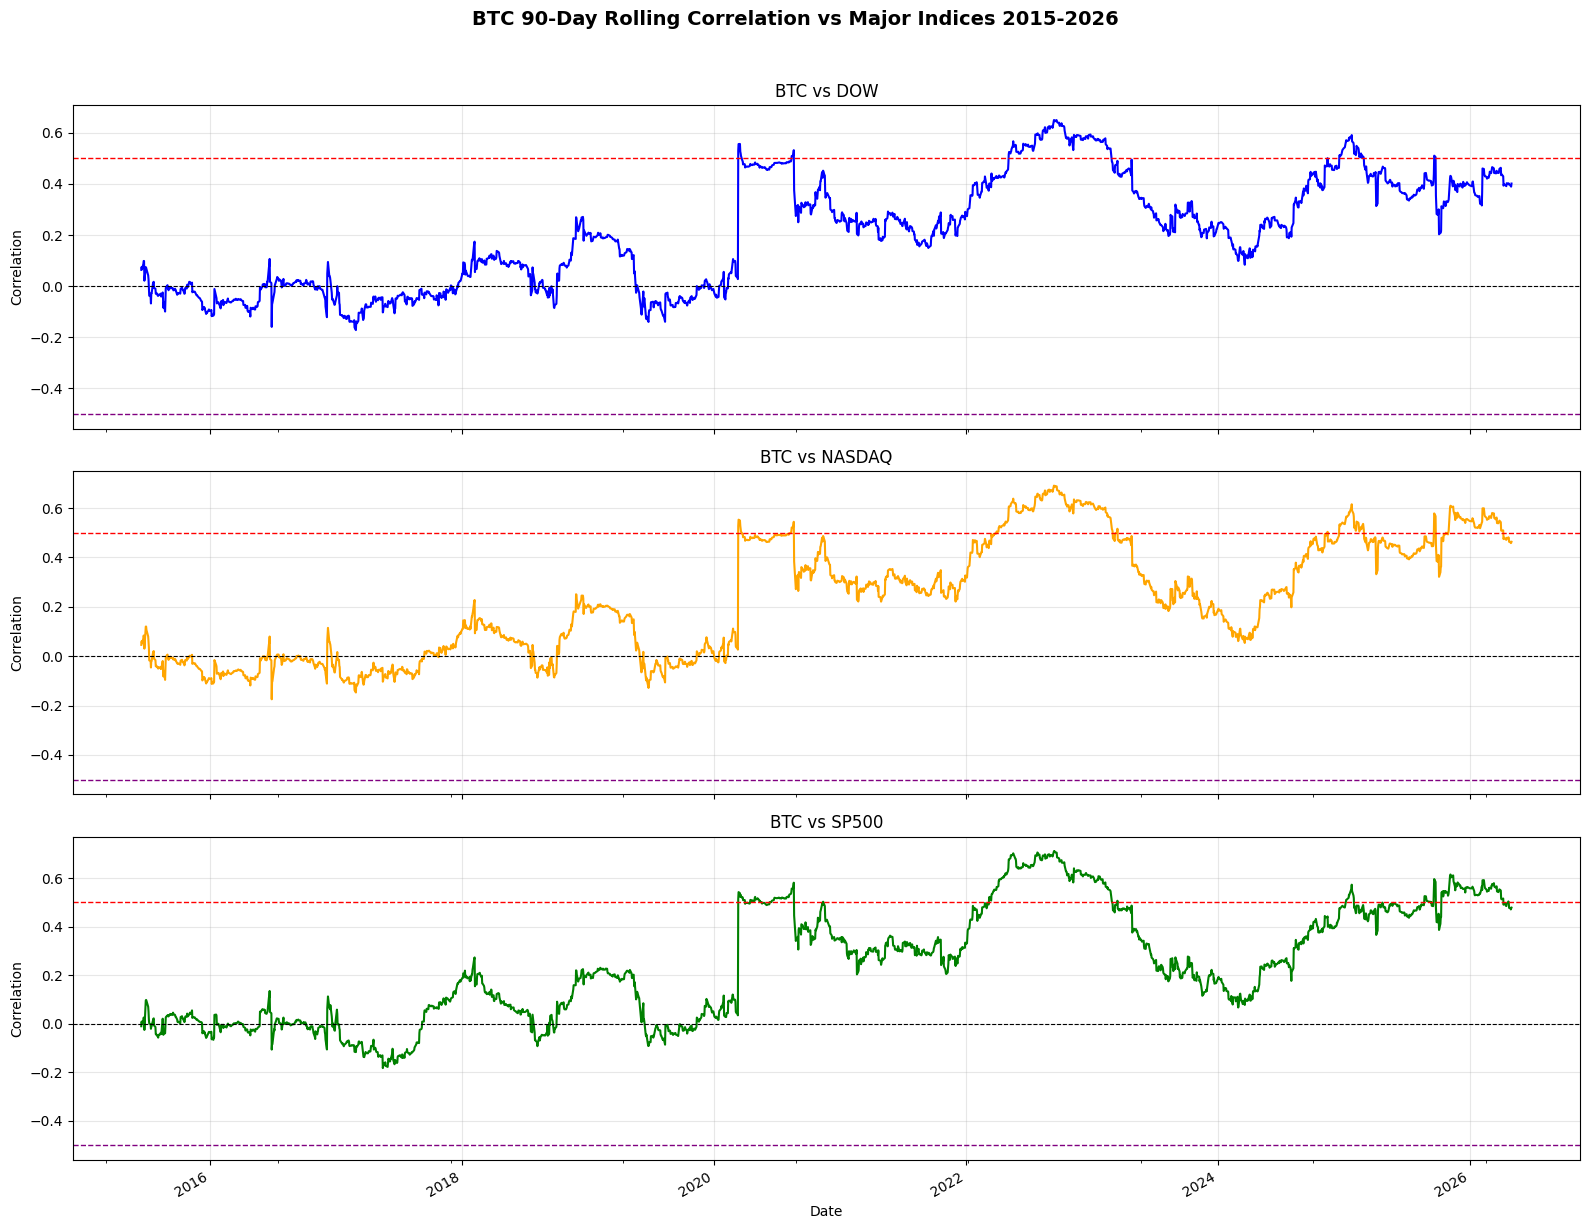

In [20]:
# Creating separate subplots with Claude

# Separate subplots for cleaner visualization
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Calculate rolling correlations
btc_dow = returns['BTC'].rolling(90).corr(returns['DOW'])
btc_nasdaq = returns['BTC'].rolling(90).corr(returns['NASDAQ'])
btc_sp500 = returns['BTC'].rolling(90).corr(returns['SP500'])

# Plot 1 - BTC vs DOW
btc_dow.plot(ax=ax1, color='blue', linewidth=1.5)
ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax1.axhline(y=-0.5, color='purple', linestyle='--', linewidth=1)
ax1.set_title('BTC vs DOW', fontsize=12)
ax1.set_ylabel('Correlation')
ax1.grid(True, alpha=0.3)

# Plot 2 - BTC vs NASDAQ
btc_nasdaq.plot(ax=ax2, color='orange', linewidth=1.5)
ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax2.axhline(y=-0.5, color='purple', linestyle='--', linewidth=1)
ax2.set_title('BTC vs NASDAQ', fontsize=12)
ax2.set_ylabel('Correlation')
ax2.grid(True, alpha=0.3)

# Plot 3 - BTC vs SP500
btc_sp500.plot(ax=ax3, color='green', linewidth=1.5)
ax3.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax3.axhline(y=-0.5, color='purple', linestyle='--', linewidth=1)
ax3.set_title('BTC vs SP500', fontsize=12)
ax3.set_ylabel('Correlation')
ax3.grid(True, alpha=0.3)

plt.suptitle('BTC 90-Day Rolling Correlation vs Major Indices 2015-2026', 
             fontsize=14, fontweight='bold', y=1.02)
plt.xlabel('Date')
plt.tight_layout()
plt.show()

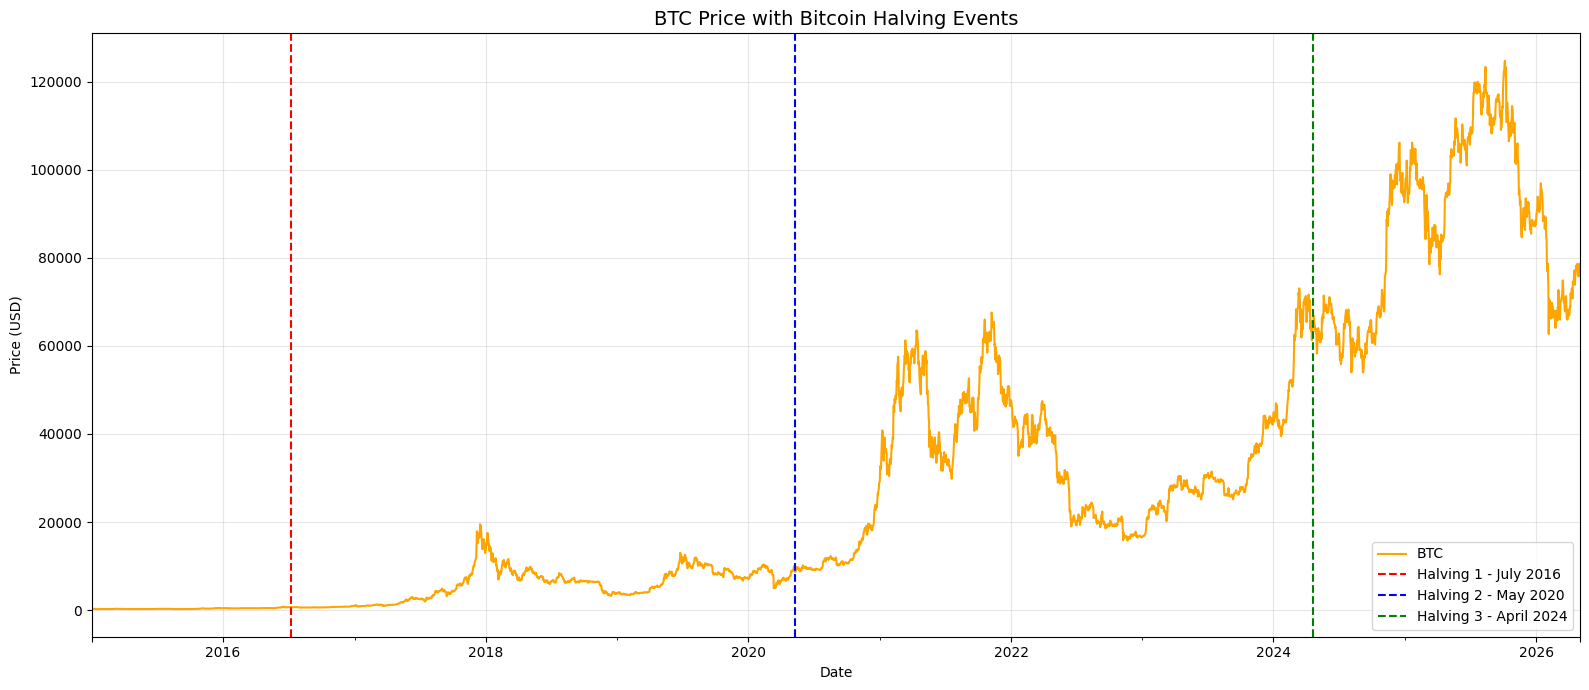

In [22]:
# BTC Price History with Halving Dates
fig, ax = plt.subplots(figsize=(16, 7))

raw_data['BTC'].plot(ax=ax, color='orange', linewidth=1.5)

# Mark the 3 halvings
ax.axvline(x='2016-07-09', color='red', linestyle='--', 
           linewidth=1.5, label='Halving 1 - July 2016')
ax.axvline(x='2020-05-11', color='blue', linestyle='--', 
           linewidth=1.5, label='Halving 2 - May 2020')
ax.axvline(x='2024-04-19', color='green', linestyle='--', 
           linewidth=1.5, label='Halving 3 - April 2024')

ax.set_title('BTC Price with Bitcoin Halving Events', fontsize=14)
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

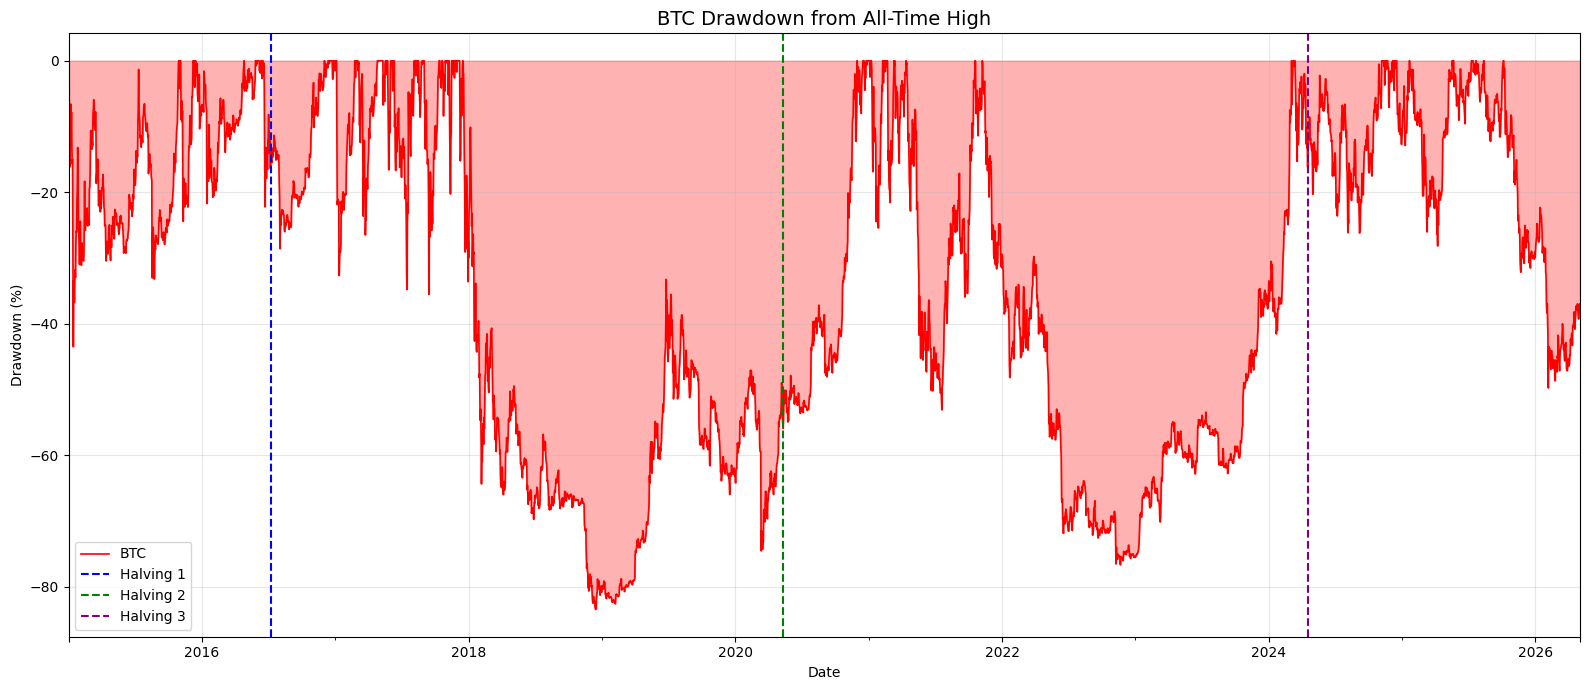

In [23]:
# BTC Drawdown Chart - shows % decline from all-time high
btc_price = raw_data['BTC'].dropna()
rolling_max = btc_price.cummax()
drawdown = (btc_price - rolling_max) / rolling_max * 100

fig, ax = plt.subplots(figsize=(16, 7))
drawdown.plot(ax=ax, color='red', linewidth=1.2)
ax.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, color='red')

ax.axvline(x='2016-07-09', color='blue', linestyle='--', linewidth=1.5, label='Halving 1')
ax.axvline(x='2020-05-11', color='green', linestyle='--', linewidth=1.5, label='Halving 2')
ax.axvline(x='2024-04-19', color='purple', linestyle='--', linewidth=1.5, label='Halving 3')

ax.set_title('BTC Drawdown from All-Time High', fontsize=14)
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Find exact cycle peaks and bottoms
btc_price = raw_data['BTC'].dropna()
rolling_max = btc_price.cummax()
drawdown = (btc_price - rolling_max) / rolling_max * 100

# Print key stats | All time high (ATH)

print("BTC ALL-TIME HIGH DATES (when drawdown = 0%):")
print("=" * 50)
ath_dates = drawdown[drawdown == 0].index
for i in range(1, len(ath_dates)):
    if (ath_dates[i] - ath_dates[i-1]).days > 30:
        print(f"  New ATH period starting: {ath_dates[i].strftime('%Y-%m-%d')} - Price: ${btc_price[ath_dates[i]]:,.0f}")

print("\n\nDEEPEST DRAWDOWNS BY YEAR:")
print("=" * 50)
for year in range(2015, 2027):
    yearly = drawdown[str(year)]
    if len(yearly) > 0:
        min_date = yearly.idxmin()
        min_val = yearly.min()
        price_at_bottom = btc_price[min_date]
        print(f"  {year}: {min_val:.1f}% on {min_date.strftime('%Y-%m-%d')} (Price: ${price_at_bottom:,.0f})")

BTC ALL-TIME HIGH DATES (when drawdown = 0%):
  New ATH period starting: 2015-10-30 - Price: $328
  New ATH period starting: 2015-12-08 - Price: $416
  New ATH period starting: 2016-04-26 - Price: $466
  New ATH period starting: 2016-05-27 - Price: $473
  New ATH period starting: 2016-12-02 - Price: $778
  New ATH period starting: 2017-02-23 - Price: $1,167
  New ATH period starting: 2017-04-26 - Price: $1,281
  New ATH period starting: 2017-08-05 - Price: $3,253
  New ATH period starting: 2017-10-12 - Price: $5,447
  New ATH period starting: 2020-11-30 - Price: $19,626
  New ATH period starting: 2021-02-08 - Price: $46,196
  New ATH period starting: 2021-04-13 - Price: $63,503
  New ATH period starting: 2021-10-19 - Price: $64,262
  New ATH period starting: 2024-03-04 - Price: $68,330
  New ATH period starting: 2024-11-06 - Price: $75,639
  New ATH period starting: 2025-01-21 - Price: $106,146
  New ATH period starting: 2025-05-18 - Price: $106,446
  New ATH period starting: 2025-07-1

In [33]:
# Correlation by Market Cycle
# Phases: Accumulation, Markup, Distribution, Markdown
# Reference: Wyckoff Market Cycle Theory + Bitcoin Halving Events
# Cycle definitions: crypto.com/university - Four Phases of Crypto Market Cycle

cycles = {
    'Accumulation (2015-2016) - Post Bear':            ('2015-01-01', '2016-12-31'),
    'Markup/Bull (2017) - Halving 1 Effect':           ('2017-01-01', '2017-12-31'),
    'Distribution & Markdown (2018-2019)':             ('2018-01-01', '2019-12-31'),
    'Accumulation (2020) - Pre Halving 2':             ('2020-01-01', '2020-05-10'),
    'Markup/Bull (2020-2021) - Institutional Entry':   ('2020-05-11', '2021-10-31'),
    'Distribution (Late 2021)':                        ('2021-11-01', '2021-12-31'),
    'Markdown/Bear (2022-2023) - Crypto Winter':       ('2022-01-01', '2023-12-31'),
    'Accumulation (Early 2024) - Pre Halving 3':       ('2024-01-01', '2024-04-18'),
    'Markup/Bull (2024-2025) - ETF & Halving 3':       ('2024-04-19', '2025-10-04'),
    'Distribution & Markdown (2025-2026)':             ('2025-10-05', '2026-05-01'),
}

print("=" * 60)
print("BTC CORRELATION BY MARKET CYCLE")
print("=" * 60)

for cycle_name, (start, end) in cycles.items():
    cycle_data = returns[start:end]
    corr_sp500  = cycle_data['BTC'].corr(cycle_data['SP500']).round(3)
    corr_nasdaq = cycle_data['BTC'].corr(cycle_data['NASDAQ']).round(3)
    corr_dow    = cycle_data['BTC'].corr(cycle_data['DOW']).round(3)
    print(f"\n{cycle_name}")
    print(f"  BTC vs S&P500:  {corr_sp500}")
    print(f"  BTC vs NASDAQ:  {corr_nasdaq}")
    print(f"  BTC vs DOW:     {corr_dow}")

print("\n" + "=" * 60)

BTC CORRELATION BY MARKET CYCLE

Accumulation (2015-2016) - Post Bear
  BTC vs S&P500:  -0.009
  BTC vs NASDAQ:  -0.027
  BTC vs DOW:     -0.012

Markup/Bull (2017) - Halving 1 Effect
  BTC vs S&P500:  0.039
  BTC vs NASDAQ:  0.019
  BTC vs DOW:     -0.017

Distribution & Markdown (2018-2019)
  BTC vs S&P500:  0.078
  BTC vs NASDAQ:  0.067
  BTC vs DOW:     0.066

Accumulation (2020) - Pre Halving 2
  BTC vs S&P500:  0.529
  BTC vs NASDAQ:  0.497
  BTC vs DOW:     0.492

Markup/Bull (2020-2021) - Institutional Entry
  BTC vs S&P500:  0.289
  BTC vs NASDAQ:  0.274
  BTC vs DOW:     0.231

Distribution (Late 2021)
  BTC vs S&P500:  0.439
  BTC vs NASDAQ:  0.391
  BTC vs DOW:     0.283

Markdown/Bear (2022-2023) - Crypto Winter
  BTC vs S&P500:  0.527
  BTC vs NASDAQ:  0.507
  BTC vs DOW:     0.476

Accumulation (Early 2024) - Pre Halving 3
  BTC vs S&P500:  0.19
  BTC vs NASDAQ:  0.18
  BTC vs DOW:     0.194

Markup/Bull (2024-2025) - ETF & Halving 3
  BTC vs S&P500:  0.431
  BTC vs NASD

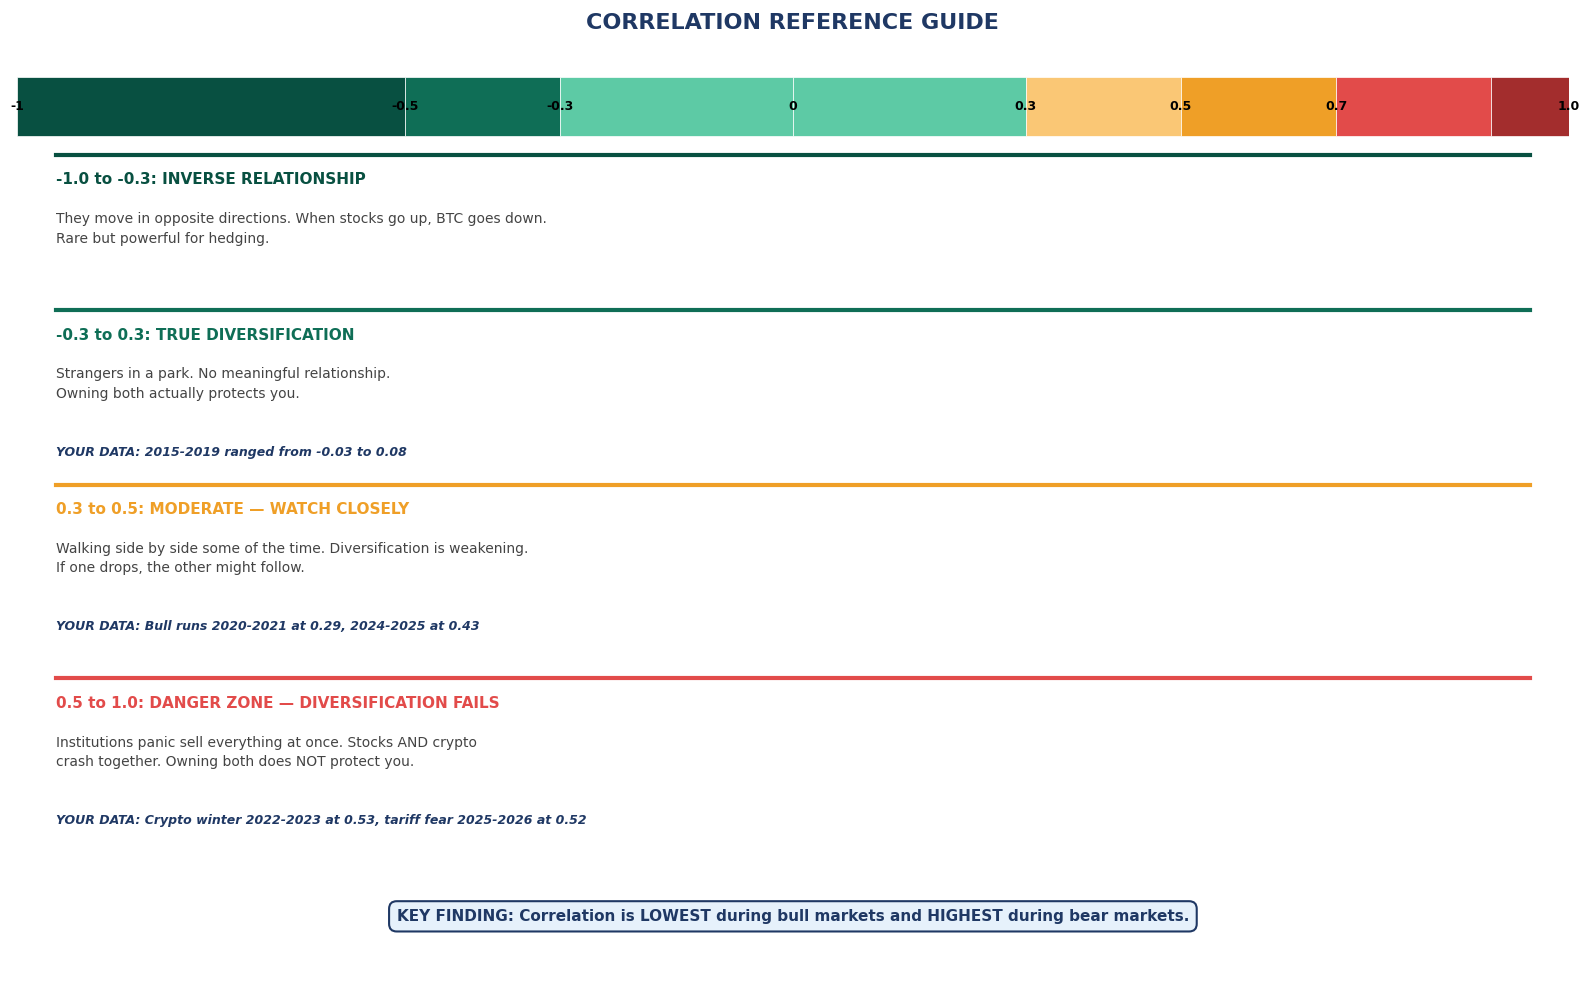

In [36]:
# Correlation Reference Guide - The Investor Translation
fig, ax = plt.subplots(figsize=(16, 10))

# Turn off the axis
ax.set_xlim(-1, 1)
ax.set_ylim(0, 10)
ax.axis('off')

# Draw the gauge bar
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

colors = ['#085041', '#0F6E56', '#5DCAA5', '#5DCAA5', '#FAC775', '#EF9F27', '#E24B4A', '#A32D2D']
ranges = [(-1, -0.5), (-0.5, -0.3), (-0.3, 0), (0, 0.3), (0.3, 0.5), (0.5, 0.7), (0.7, 0.9), (0.9, 1)]

for (start, end), color in zip(ranges, colors):
    width = end - start
    ax.barh(9, width, left=start, height=0.6, color=color, edgecolor='white', linewidth=0.5)

# Labels on the bar
for val in [-1, -0.5, -0.3, 0, 0.3, 0.5, 0.7, 1.0]:
    ax.text(val, 9, f'{val}', ha='center', va='center', fontsize=9, 
            color='black', fontweight='bold')

# Title
ax.text(0, 9.8, 'CORRELATION REFERENCE GUIDE', ha='center', fontsize=16, 
        fontweight='bold', color='#1F3864')

# Zone descriptions
zones = [
    (7.8, '#085041', '-1.0 to -0.3: INVERSE RELATIONSHIP',
     'They move in opposite directions. When stocks go up, BTC goes down.\nRare but powerful for hedging.', ''),

    (6.2, '#0F6E56', '-0.3 to 0.3: TRUE DIVERSIFICATION',
     'Strangers in a park. No meaningful relationship.\nOwning both actually protects you.', 
     'YOUR DATA: 2015-2019 ranged from -0.03 to 0.08'),

    (4.4, '#EF9F27', '0.3 to 0.5: MODERATE — WATCH CLOSELY',
     'Walking side by side some of the time. Diversification is weakening.\nIf one drops, the other might follow.',
     'YOUR DATA: Bull runs 2020-2021 at 0.29, 2024-2025 at 0.43'),

    (2.4, '#E24B4A', '0.5 to 1.0: DANGER ZONE — DIVERSIFICATION FAILS',
     'Institutions panic sell everything at once. Stocks AND crypto\ncrash together. Owning both does NOT protect you.',
     'YOUR DATA: Crypto winter 2022-2023 at 0.53, tariff fear 2025-2026 at 0.52'),
]

for y, color, title, desc, data in zones:
    ax.plot([-0.95, 0.95], [y + 0.7, y + 0.7], color=color, linewidth=3)
    ax.text(-0.95, y + 0.4, title, fontsize=11, fontweight='bold', color=color)
    ax.text(-0.95, y - 0.2, desc, fontsize=10, color='#444444', linespacing=1.5)
    if data:
        ax.text(-0.95, y - 0.8, data, fontsize=9, fontweight='bold', 
                color='#1F3864', style='italic')

# Key finding box
ax.text(0, 0.6, 'KEY FINDING: Correlation is LOWEST during bull markets and HIGHEST during bear markets.',
        ha='center', fontsize=11, fontweight='bold', color='#1F3864',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#E6F1FB', edgecolor='#1F3864', linewidth=1.5))

plt.tight_layout()
plt.show()

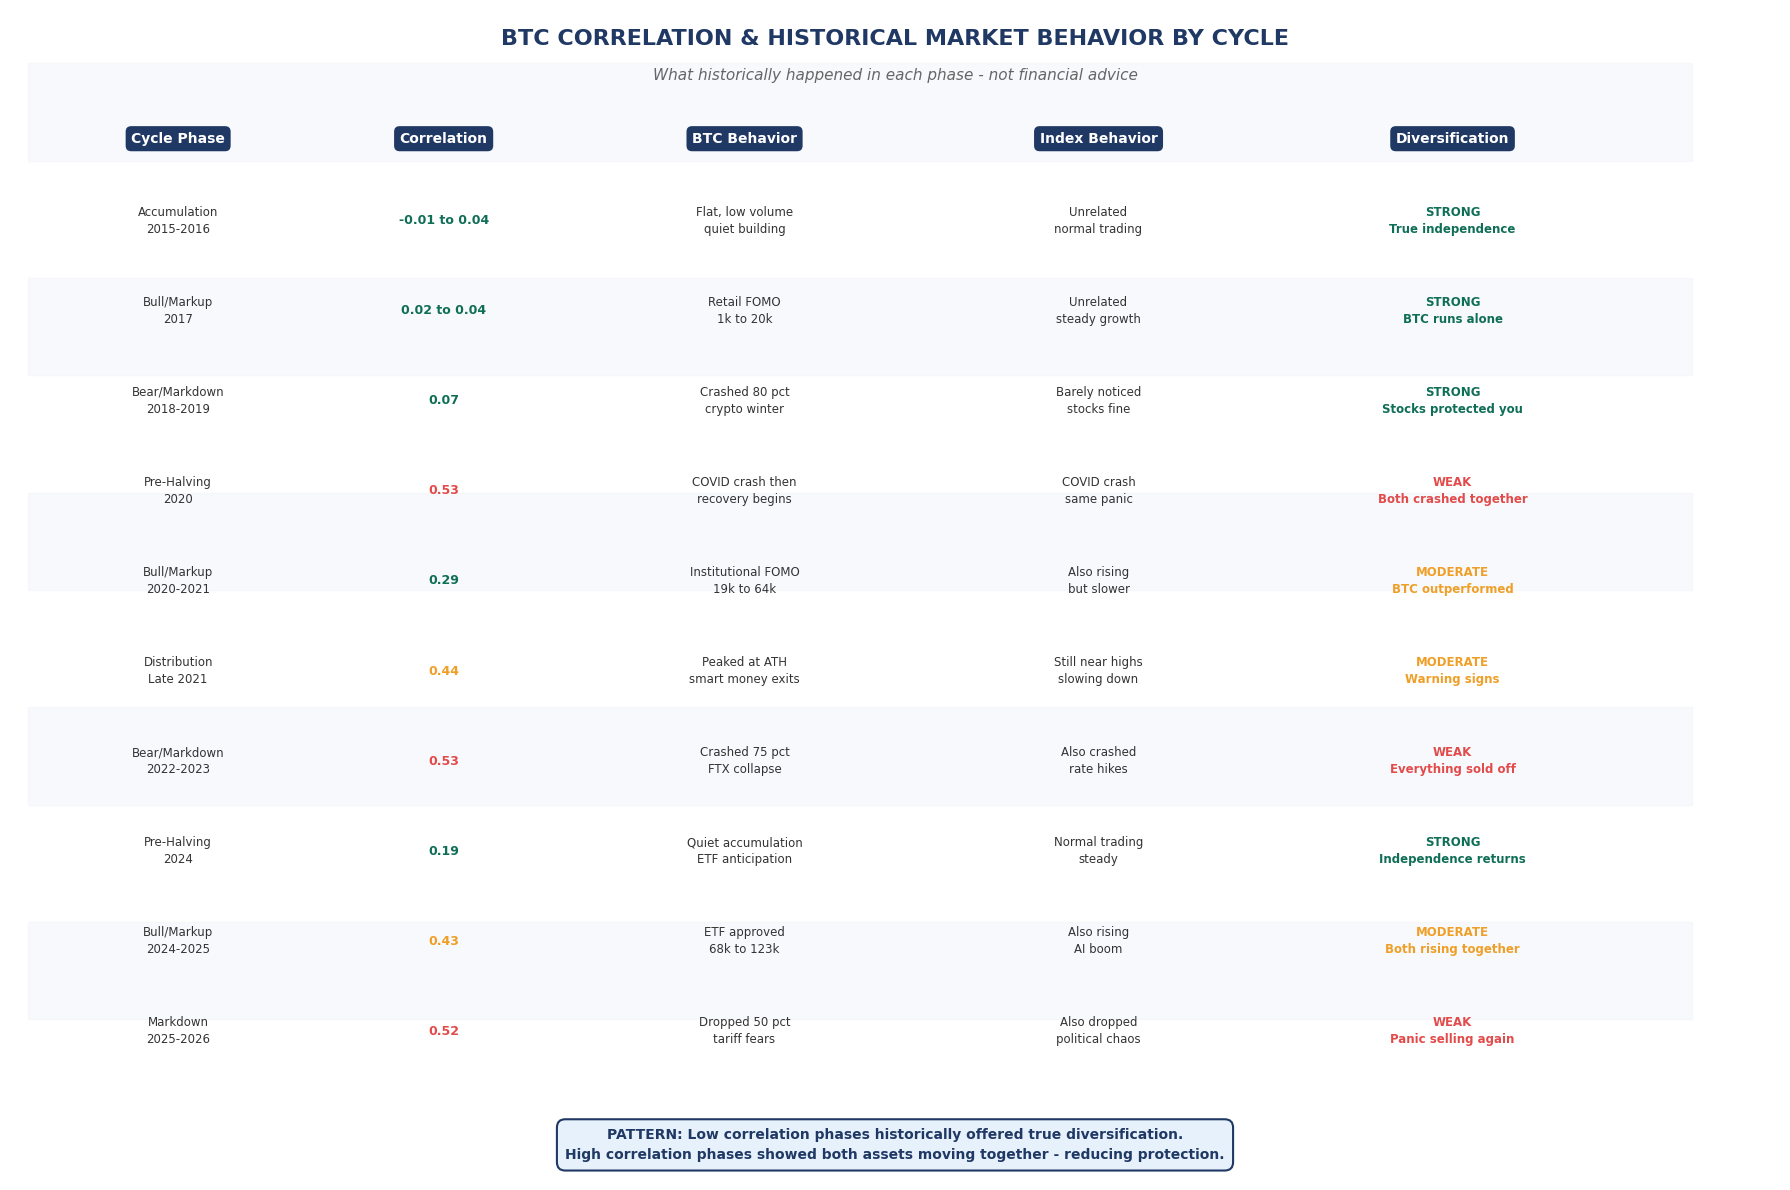

In [39]:
# Investment Context by Market Cycle Phase
# NOTE: This is historical analysis, not financial advice

fig, ax = plt.subplots(figsize=(18, 12))
ax.axis('off')

ax.text(0.5, 0.97, 'BTC CORRELATION & HISTORICAL MARKET BEHAVIOR BY CYCLE', 
        ha='center', fontsize=16, fontweight='bold', color='#1F3864',
        transform=ax.transAxes)
ax.text(0.5, 0.94, 'What historically happened in each phase - not financial advice', 
        ha='center', fontsize=11, color='#666666', style='italic',
        transform=ax.transAxes)

headers = ['Cycle Phase', 'Correlation', 'BTC Behavior', 'Index Behavior', 'Diversification']

rows = [
    ['Accumulation\n2015-2016', '-0.01 to 0.04', 'Flat, low volume\nquiet building', 'Unrelated\nnormal trading', 'STRONG\nTrue independence'],
    ['Bull/Markup\n2017', '0.02 to 0.04', 'Retail FOMO\n1k to 20k', 'Unrelated\nsteady growth', 'STRONG\nBTC runs alone'],
    ['Bear/Markdown\n2018-2019', '0.07', 'Crashed 80 pct\ncrypto winter', 'Barely noticed\nstocks fine', 'STRONG\nStocks protected you'],
    ['Pre-Halving\n2020', '0.53', 'COVID crash then\nrecovery begins', 'COVID crash\nsame panic', 'WEAK\nBoth crashed together'],
    ['Bull/Markup\n2020-2021', '0.29', 'Institutional FOMO\n19k to 64k', 'Also rising\nbut slower', 'MODERATE\nBTC outperformed'],
    ['Distribution\nLate 2021', '0.44', 'Peaked at ATH\nsmart money exits', 'Still near highs\nslowing down', 'MODERATE\nWarning signs'],
    ['Bear/Markdown\n2022-2023', '0.53', 'Crashed 75 pct\nFTX collapse', 'Also crashed\nrate hikes', 'WEAK\nEverything sold off'],
    ['Pre-Halving\n2024', '0.19', 'Quiet accumulation\nETF anticipation', 'Normal trading\nsteady', 'STRONG\nIndependence returns'],
    ['Bull/Markup\n2024-2025', '0.43', 'ETF approved\n68k to 123k', 'Also rising\nAI boom', 'MODERATE\nBoth rising together'],
    ['Markdown\n2025-2026', '0.52', 'Dropped 50 pct\ntariff fears', 'Also dropped\npolitical chaos', 'WEAK\nPanic selling again'],
]

col_x = [0.02, 0.18, 0.32, 0.52, 0.72]
col_widths = [0.15, 0.13, 0.19, 0.19, 0.19]

y = 0.89
for i, header in enumerate(headers):
    ax.text(col_x[i] + col_widths[i]/2, y, header, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#1F3864', edgecolor='none'),
            transform=ax.transAxes)

div_colors = {
    'STRONG': '#0F6E56',
    'MODERATE': '#EF9F27', 
    'WEAK': '#E24B4A'
}

for row_idx, row in enumerate(rows):
    y = 0.82 - (row_idx * 0.077)
    bg_color = '#F0F4FA' if row_idx % 2 == 0 else '#FFFFFF'
    
    ax.axhspan(y - 0.035, y + 0.035, xmin=0.01, xmax=0.95, 
               color=bg_color, alpha=0.5, transform=ax.transAxes)
    
    for col_idx, cell in enumerate(row):
        if col_idx == 4:
            strength = cell.split('\n')[0]
            color = div_colors.get(strength, '#666666')
            ax.text(col_x[col_idx] + col_widths[col_idx]/2, y, cell, 
                    ha='center', va='center', fontsize=8.5, color=color,
                    fontweight='bold', transform=ax.transAxes, linespacing=1.4)
        elif col_idx == 1:
            val_str = row[1].split(' to ')[-1] if ' to ' in row[1] else row[1]
            val = float(val_str)
            if val >= 0.5:
                color = '#E24B4A'
            elif val >= 0.3:
                color = '#EF9F27'
            else:
                color = '#0F6E56'
            ax.text(col_x[col_idx] + col_widths[col_idx]/2, y, cell,
                    ha='center', va='center', fontsize=9, color=color,
                    fontweight='bold', transform=ax.transAxes, linespacing=1.4)
        else:
            ax.text(col_x[col_idx] + col_widths[col_idx]/2, y, cell,
                    ha='center', va='center', fontsize=8.5, color='#333333',
                    transform=ax.transAxes, linespacing=1.4)

ax.text(0.5, 0.03, 
        'PATTERN: Low correlation phases historically offered true diversification.\n'
        'High correlation phases showed both assets moving together - reducing protection.',
        ha='center', va='center', fontsize=10, color='#1F3864', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#E6F1FB', edgecolor='#1F3864', linewidth=1.5),
        transform=ax.transAxes, linespacing=1.6)

plt.tight_layout()
plt.show()
